In [ ]:
import time
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input

In [ ]:
path = "/content/drive/MyDrive/Aprendizado - Notebooks Colab/ResNet50V2 Transfer Learning/archive"
train_path = path + "/train"
val_path = path + "/val"
test_path = path + "/test"

# ResNet50V2 Transfer Learning on a Chest X-Ray Pneumonia Classification

# Equipe:
*   Carlos Henrique Miranda Esteves;
*   Lucas Almeida Miralha de Figueiredo;
*   Lucas Andrey Nunes de Aragão.

# Overview:

O projeto "ResNet50V2 Transfer Learning on a Chest X-Ray Pneumonia Classification" é baseado na pesquisa [Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning](https://www.cell.com/cell/fulltext/S0092-8674(18)30154-5), no qual os pesquisadores utilizaram o método de transfer learning na classificação de degeneração macular relacionada à idade e edema macular diabético através de imagens tomografia de coerência óptica (OCT). Os pesquisadores também demonstraram a eficiência do modelo na classificação pediátrica de pneumonia com base em imagens de raio-x do toráx.

Os dados utilizados neste trabalho foram extraídos do repositório Kaggle: [Chest X‑Ray Pneumonia — Balanced Dataset](https://www.kaggle.com/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/data). As imagens deste repositório são as mesmas imagens utilizadas no estudo acima. Para o nosso experimento, configuramos o modelo CNN ResNet50V2 para classificação de imagens através do procedimento de transfer learning via Keras Tensorflow. Outros modelos CNN também podem ser utilizados para a tarefa de classificação de imagens.

Este notebook colab é responsável por: processar os dados, configurar e adaptar o modelo ResNet50V2 via transfer learning, treinamento do modelo, plotagem e análise de dados e exploração do GridSearch

# Direitos Autorais

As imagens utilizadas neste notebook colab são de autoria de Aurélien Geron, autor do livro Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow. Imagens, explicações teóricas do funcionamento do uso de CNN's e código fonte são de autoria de Aurélien Geron. Link para aquisição do livro: [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow](https://www.amazon.com.br/Mãos-Obra-Aprendizado-Scikit-Learn-Inteligentes/dp/8550826456/ref=sr_1_2?crid=12PQ0NFG10U49&dib=eyJ2IjoiMSJ9.N97X5WDhjZrNKhN1w0I4znhJnfHqAy9_UsfvUtPRPplPQNhm-3qRg6J_DPD4UF7ua3frSmbDIzTZzenfqLo25KoWZqmUZnWcIPLx3xvdASTsdpk7YjbdOoUIt22sF_jJ2oz5qGsIQp-0EhgUJVkg6dIXVh_pTwtkr7Dp3Hz4QKqYLmuLaKtXe88Nyrabddle.HOR18zUrW2LwoouaHiVCQ_lihQ5iDr4lKWHz63BD_Y4&dib_tag=se&keywords=mãos+a+obra+aprendizado+de+maquina&qid=1774744923&sprefix=%2Caps%2C212&sr=8-2)

# Uso de IA Generativa

Durante a confecção deste experimento, a IA generativa Gemini 3 - Raciocínio foi utilizada nos seguintes aspectos:


*   Fundamentação Teórica e Conceitual (aprendizado teórico);
*   Adaptação do Código do Autor Para o Modelo Utilizado Neste Experimento;
*   Decisões Relacionado ao Uso de GPU;
*   Edições, Formulações e Contribuições de Código;
*   Auxílio na Tomada de Decisões Relacionadas a Partes Críticas de Configuração da CNN;
*   Escrita Parcial de Texto.





# 1°: Processamento de Dados

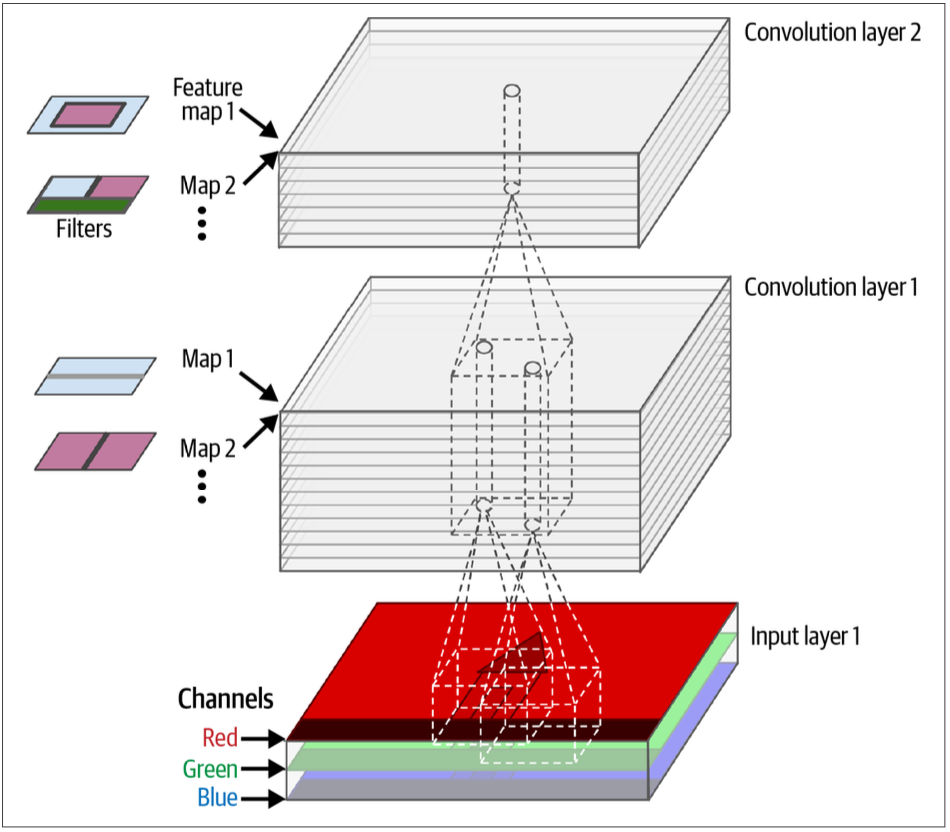
A primeira etapa antes de executar o ResNet50V2 consiste em tratar os dados. No nosso caso, os dados que serão introduzidos no modelo são imagens de raios-x do tórax. O modelo ResNet50V2 tem entradas de 224 por 224. Por padrão, o ResNet50V2 Transfer Learning tem arquitetura que aceita entradas RGB (canal 3 de entrada), nosso dataset tem somente 1 canal de tons de cinza. O modelo ResNet50V2 possui 25.5 milhões de parâmetros.

Na primeira etapa, estamos preocupados em realizar as seguintes tarefas:


1.   Padronizar o tamanho dos dados para os inputs do ResNet50V2;
2.   Padronizar o tamanho do canal dos dados para para os inputs do ResNet50V2;
3.   Dividir o dataset em: treino, validação e teste;
4.   Realizar o processo de augmentação de dados.



In [ ]:
# Tamanho do Batch de Dados
BATCH_SIZE = 64

# Padronização do tamanho das imagens para o input do ResNet50V2
IMG_SIZE = (224, 224)

# Mesmo sendo um canal (tons de cinza), o ResNet50V2 de transfer learning
# espera trabalhar com RGB
IMG_SHAPE = IMG_SIZE + (3,)

# Carga do dataset de treinamento (necessário embaralhamento dos dados)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

# Carga do dataset de treinamento
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

# Carga do dataset de treinamento (caso necessário)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

Found 6800 files belonging to 2 classes.
Found 6800 files belonging to 2 classes.
Found 30 files belonging to 2 classes.


In [ ]:
# Augmentação de dados:
# Apesar do dataset possui 6800 dados, ainda precisamos do processo de augmenta-
# de dados. A augmentação de dados é um processo que permite expandir a amostra
# de dados originais aplicando flips, rotações e zooms na amostra original, ge-
# rando "novos" dados.

data_augmentation = tf.keras.Sequential([
                    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
                    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
                    tf.keras.layers.RandomZoom(0.1, seed=42)
])

# 2°: Personalização do Modelo Transfer Learning ResNet50V2

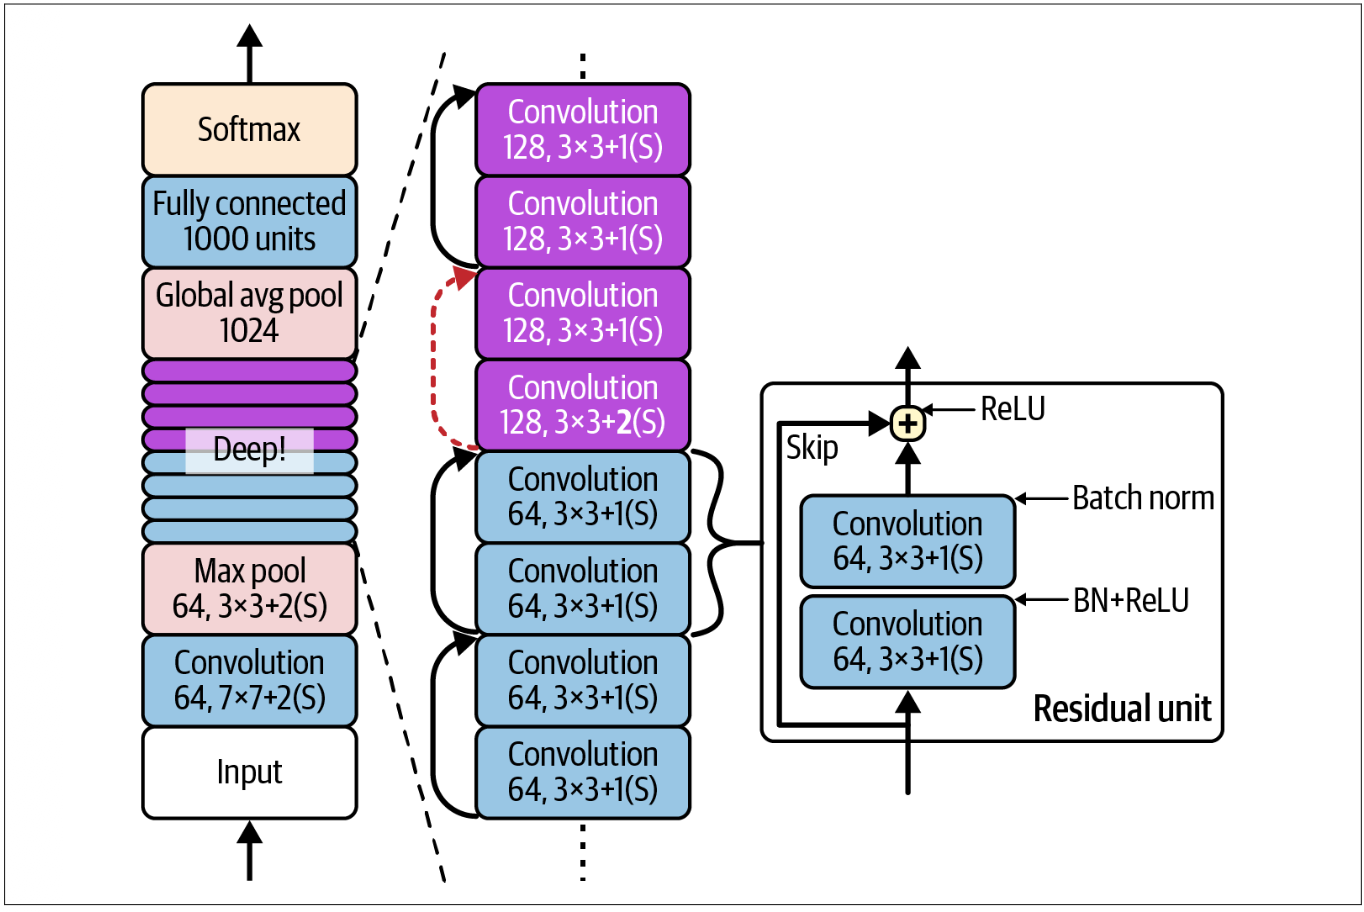

Nesta seção, não implementaremos o modelo ResNet50 do 0. Ao invés disso, vamos recorrer a técnica do transfer learning: vamos utilizar uma CNN pronta capaz de reconhecer imagens (em torno de 1000 classes) com parâmetros prontos e vamos reconfigurar o modelo para o nosso problema: classificar as imagens em somente duas classes: com pneumonia e sem pneumonia.

Para tornar isso possível, precisamos fazer umas modificações, a primeira delas é o topo do modelo. Como é possível ver na imagem de cima, o topo apresenta três unidades importantes: saida softmax, camada densa conectada com 1000 unidades e um global avarage pool de 1024 pontos. Nosso objetivo é gerar somente duas saídas, portanto, precisamos remover a classificação de 1000 unidades

In [ ]:
# Importação do modelo ResNet50V2, excluindo o topo. Os parâmetros iniciais são
# os parâmetros do imagenet
base_model = ResNet50V2(input_shape=IMG_SHAPE,
                         include_top=False,
                         weights='imagenet')

# O transfer learning deve preservar partes dos parâmetros da CNN original, en-
# quanto utiliza o restante dos parâmetros para treinar e classificar novas ima-
# gens. Por isso, o código abaixo congela as camadas iniciais.
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
# Configurando o tamanho do Input como (224, 224, 3)
inputs = tf.keras.Input(shape=IMG_SHAPE)

# Adiciona o processo de augmentação de dados no treinamento
x = data_augmentation(inputs)

# Aqui pre processamos as imagens. Alguns modelos precisam que a imagem vá de 0
# a 1, outros precisam que a imagem vá de -1 a 1.
x = preprocess_input(x)

# Configurando saída do modelo
x = base_model(x, training=False)

# Configurações da Camado do Topo

#  Configuração do Pooling Layer
x = layers.GlobalAveragePooling2D()(x)

# Configuração da Camada Densa
# Configuração da camada densa com 128 unidades de informação (tente mudar para
# ver se a precisão aumenta ou diminui)
x = layers.Dense(128, activation='relu')(x)

# Configuração do dropout para desativação de 30% dos neurônios durante os testes
x = layers.Dropout(0.3)(x)

# Camada final com um único neurônio, podendo ter o diagnóstico de 0.0 a 1.0
outputs = layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,201 (90.89 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

# 3°: Treinamento

Por fim, a ultima etapa é a etapa de treinamento. Aqui temos algumas configurações importantes: otimizador, parâmetros do otimizador, metricas que desejamos analisar etc. As principais métricas que precisamos utilizar são: accuracy, precisão, recall e auc. Abaixo, definimos alguns dos possíveis resultados do nosso treinamento e classificação:

*   **Verdadeiro Positivo (TP):** O modelo classificou como "Doente" e a pessoa está doente.
*   **Verdadeiro Negativo (TN):** O modelo classificou como "Saudável" e a pessoa está saudável.
*   **Falso Positivo (FP):** O modelo classificou como "Doente", mas a pessoa está saudável (Alarme Falso).
*   **Falso Negativo (FN):** O modelo classificou como "Saudável", mas a pessoa está doente (Erro Perigoso).

Todos esse possíveis resultados que podemos obter da nossa classificação, permite criar algumas métricas de avaliação do desempenho do modelo:



1.   **Accuracy (Acurácia):** de tudo o que o modelo previu, quanto ele acertou no total (tanto positivos quanto negativos).
$$\text{Acurácia} = \frac{TP + TN}{\text{Total de casos}}$$

2.   **Precision (Precisão):** De todos os que o modelo classificou como positivos, quantos eram realmente positivos?
$$\text{Precisão} = \frac{TP}{TP + FP}$$

3.   **Recall:** De todos os que são realmente positivos na vida real, quantos o modelo conseguiu encontrar? Devemos considerar essa métrica para verificar os falsos positivos e evitar submeter uma pessoa a um tratamento desnecessário
$$\text{Recall} = \frac{TP}{TP + FN}$$

4.   **Area Under the Curve (Área Sobre a Curva):** mede a capacidade de separação do modelo. Ou seja, o quão bem o seu modelo consegue distinguir entre a classe 0 e a classe 1.

In [ ]:
# Aqui compilamos várias informações de uma vez: otimizador, entropia binária
# cruzada, métricas como a precisão, accuracy, recall e auc.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[
                  'accuracy',
                  tf.keras.metrics.Precision(name='precision'),
                  tf.keras.metrics.Recall(name='recall'),
                  tf.keras.metrics.AUC(name='auc')
              ])

In [ ]:
# Aqui configuramos uma parada. Caso a rede não melhore, devemos interromper o
# processo de aprendizado
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=5,
                                                  restore_best_weights=True)

In [ ]:
# Por fim, executamos o processo de treinamento com 10 épocas
# Nota: uma época é quantas vezes o modelo vai varrer o dataset de treinamento
# do início ao fim. Esse procedimento é necessário para que o modelo aprenda
# através do conjunto de treinamento. Varrer uma única vez nunca é o suficiente
epochs = 10
print(f'Iniciando treino de {epochs} épocas com base congelada...')
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=validation_dataset,
    callbacks=[early_stopping]
)

Iniciando treino de 10 épocas com base congelada...
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 58s 475ms/step - accuracy: 0.9206 - auc: 0.9760 - loss: 0.1972 - precision: 0.9256 - recall: 0.9147 - val_accuracy: 0.9538 - val_auc: 0.9924 - val_loss: 0.1218 - val_precision: 0.9771 - val_recall: 0.9294
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.9522 - auc: 0.9874 - loss: 0.1365 - precision: 0.9542 - recall: 0.9500 - val_accuracy: 0.9365 - val_auc: 0.9938 - val_loss: 0.1538 - val_precision: 0.9911 - val_recall: 0.8809
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 241ms/step - accuracy: 0.9594 - auc: 0.9911 - loss: 0.1170 - precision: 0.9610 - recall: 0.9576 - val_accuracy: 0.9360 - val_auc: 0.9943 - val_loss: 0.1546 - val_precision: 0.9930 - val_recall: 0.8782
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.9616 - auc: 0.9917 - loss: 0.1094 - precision: 0.9675 - recall: 0.9553 - val_accuracy: 0.9631 - val_auc: 0.9959 - val_loss: 0.0927 - val_precisi

# 4°: Plotagem dos resultados

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

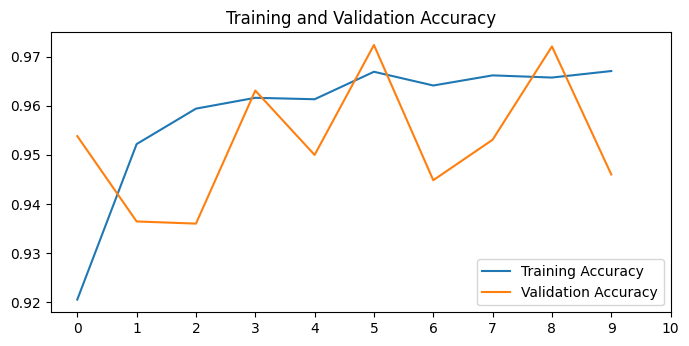

In [ ]:
# Gráfico de acurácias (treino e validação)
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xticks(range(0, 11))
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

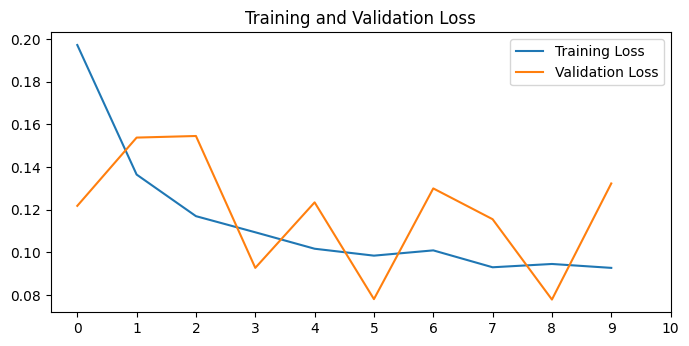

In [ ]:
# Gráfico de perdas (treino e validação)
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xticks(range(0, 11))
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

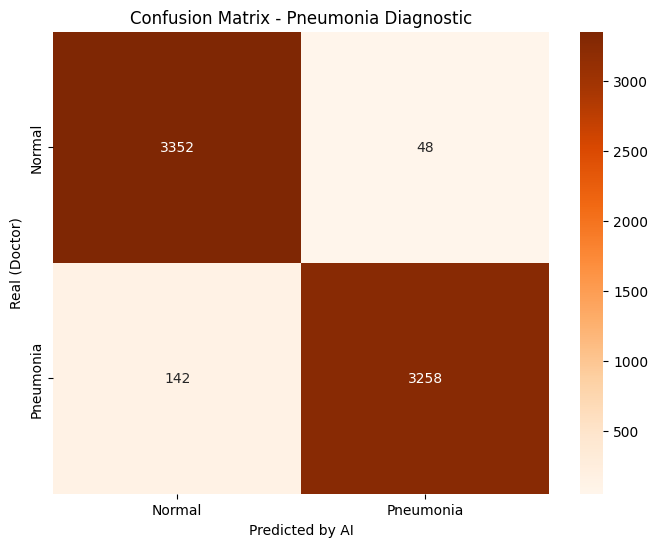

              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97      3400
   Pneumonia       0.99      0.96      0.97      3400

    accuracy                           0.97      6800
   macro avg       0.97      0.97      0.97      6800
weighted avg       0.97      0.97      0.97      6800



In [ ]:
# Aqui, plotamos uma matriz de confusão
y_true = []
y_pred = []

# Pegando as imagens e os labels do dataset de validação
for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    # Como a saída da Sigmoid é probabilidade (0 a 1), usamos o limiar de 0.5
    y_pred.extend((preds > 0.5).astype(int))

# Aqui geramos a matriz
cm = confusion_matrix(y_true, y_pred)

# Plotando o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted by AI')
plt.ylabel('Real (Doctor)')
plt.title('Confusion Matrix - Pneumonia Diagnostic')
plt.show()

# Relatório completo (Precision, Recall, F1)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

# 5°: Implementação do Gridsearch

Ainda precisamos implementar a estratégia do Gridsearch. O Gridsearch é uma técnica de otimização de hiperparâmetros como melhor configuração de otimizador, otimizador, número de neurônios em uma camada etc. Até o momento, temos uma configuração padrão do nosso ResNet50V2. No entanto, questionamentos básicos podem surgir: o que acontece se modificarmos o otimizador? E se mudarmos a configuração de dropout? Existe alguma configuração hiperparamétrica que garante melhora da acurácia? Nesta seção, implementaremos a estratégia do Gridsearch para melhorar a acurácia do modelo.

Nosso experimento se concentrará na busca dos seguintes hiperparâmetros. Por convenção, estamos testanto 12 combinações:



*   **Otimizadores:** Vamos testar dois otimizadores baseados em gradiente, ADAM e SGD.
*   **Learning Rates:** Utilizaremos learning rates de 1e-2 e 1e-3
*   **Dropouts:** Configuraremos 3 possíveis taxas dropouts 20%, 30% e 50%

Para facilitar a execução do experimento, criamos uma função chamada build_resnet_model. Essa função será responsável por fazer exatamente o que a seção 2 (Personalização do Modelo Transfer Learning ResNet50V2) faz, só que de maneira compacta e pronta para receber os hiperparâmetros e configurar um modelo só para um experimento.







In [ ]:
# Listas de hiperparâmetros
optimizers = ['adam', 'sgd']
learning_rates = [1e-2, 1e-3, 1e-4]
dropouts = [0.2, 0.3, 0.5]

# Aqui armazenamos os registros
results = []

In [ ]:
def build_resnet_model(opt_name, lr, dr):
    # 1. Carregar modelo base
    base_model = ResNet50V2(input_shape=IMG_SHAPE,
                            include_top=False,
                            weights='imagenet')

    for layer in base_model.layers:
      layer.trainable = False

    # 2. Construção do Grafo (API Funcional)
    img_input = tf.keras.Input(shape=IMG_SHAPE, name="original_input")

    x = data_augmentation(img_input)
    x = preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dr)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    # 3. Definição do Modelo (Input original -> Output final)
    model = tf.keras.Model(img_input, outputs)

    # 4. Configuração do Otimizador
    if opt_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
count = 1
for opt_name in optimizers:
    for lr in learning_rates:
        for dr in dropouts:
            print(f"\nRodando Combinação {count}/18: Opt={opt_name}, LR={lr}, Dropout={dr}")

            # Função build_resnet_model declarada acima
            model = build_resnet_model(opt_name, lr, dr)

            # Callback para early stopping
            early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                                  patience=5,
                                                  restore_best_weights=True)
            # Treino para o Grid Search
            start_time = time.time()
            history = model.fit(
                train_dataset,
                validation_data=validation_dataset,
                epochs=10,
                verbose=1,
                callbacks=[early_stopping]
            )
            end_time = time.time()

            # Registrar resultados
            max_val_acc = max(history.history['val_accuracy'])
            results.append({
                'combinacao': count,
                'optimizer': opt_name,
                'lr': lr,
                'dropout': dr,
                'val_accuracy': max_val_acc,
                'training_time': end_time - start_time
            })

            count += 1
            # Limpar memória para a próxima rodada (isso evita explosão da minha
            # GPU)
            tf.keras.backend.clear_session()

# Converter para DataFrame para o relatório
df_results = pd.DataFrame(results)


Rodando Combinação 1/18: Opt=adam, LR=0.01, Dropout=0.2
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 265ms/step - accuracy: 0.8847 - loss: 0.5765 - val_accuracy: 0.9501 - val_loss: 0.1331
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 243ms/step - accuracy: 0.9481 - loss: 0.1428 - val_accuracy: 0.9621 - val_loss: 0.1044
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.9499 - loss: 0.1332 - val_accuracy: 0.9312 - val_loss: 0.1677
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 243ms/step - accuracy: 0.9568 - loss: 0.1211 - val_accuracy: 0.9649 - val_loss: 0.0880
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.9582 - loss: 0.1084 - val_accuracy: 0.9447 - val_loss: 0.1444
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.9576 - loss: 0.1121 - val_accuracy: 0.9488 - val_loss: 0.1389
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 245ms/step - accuracy: 0.9613 - loss: 0.1050 - val_accuracy: 0.9512 - val_loss: 0.1187
Epoch 8/10
107/107 ━━━━━━━

In [ ]:
# Melhor combinação por acurácia de validação.
df_results = df_results.sort_values(by='val_accuracy', ascending=False)
display(df_results)

best_config = df_results.iloc[0]

,combinacao,optimizer,lr,dropout,val_accuracy,training_time
4,5,adam,0.0010,0.3,0.976471,267.748643
3,4,adam,0.0010,0.2,0.975147,267.898878
2,3,adam,0.0100,0.5,0.971029,269.020784
0,1,adam,0.0100,0.2,0.970882,268.420148
1,2,adam,0.0100,0.3,0.967647,269.608827
6,7,adam,0.0001,0.2,0.967206,267.788172
5,6,adam,0.0010,0.5,0.965735,267.431849
7,8,adam,0.0001,0.3,0.965441,267.817915
8,9,adam,0.0001,0.5,0.963824,267.870632
9,10,sgd,0.0100,0.2,0.961029,267.862596
